# K-Nearest Neighbor

The k-Nearest Neighbors ($\kappa$NN) classifier is probably the most simple classifier. Yet, it is a good baseline, since it is easy to understand, it can be analyzed in tems of Bayes-optimality and it performs also quite well. The $\kappa$NN classifier makes predictions based on the majority class among the nearest training examples. It is non-parametric and instance-based, meaning that it does not use a parametrized function class from which the classifier is determined by learning the parameters. Instead, it directly computes the prediction from the training data.

## Inference 
Given a (training) dataset $\mathcal{D}=\{(\vvec{x}_1,y_1),\ldots, (\vvec{x}_n,y_n)\}$ and a distance metric $dist(\vvec{x}_i,\vvec{x}_j)\in\mathbb{R}_+$ returning the nonnegative distance between two vectors $\vvec{x}_i,\vvec{x}_j\in\mathbb{R}^d$. We define the function $\kappa NN(\vvec{x})=\{i_1,\ldots, i_k\}$ returning the indices of the $\kappa$ closest neighbors of $\vvec{x}$ in $\mathcal{D}$. That is, $\kappa NN(\vvec{x})$ contains the $\kappa$ indices $i$ whose training points have the smallest distance $dist(\mathbf{x},\mathbf{x}_i)$ to $\mathbf{x}$.
The kNN classifier uses the training data to predict for a given data point the class that occurs the most frequently among the $\kappa$ nearest neighbors.
```{prf:definition} kNN classifier
The kNN classifier returns the class probabilities estimated from the $\kappa$ neighbors: 
\begin{align*}
f_{knn}(\vvec{x})_l = \frac{1}{\kappa} \lvert\{i\in \kappa NN(x)\mid y_i=l\}\rvert    
\end{align*}
As a result, the class predictions are made by a majority vote of the nearest neighbors:
\begin{align*}
\hat{y}_{\kappa nn}(\vvec{x}) &= \argmax_l f_{\kappa nn}(\vvec{x})_l\\
&= \argmax_l \lvert\{i\in \kappa NN(x)\mid y_i=l\}\rvert 
\end{align*}
```
The principle of the kNN classifier is very simple. Below you see an illustration about the prediction process. The classifier relies on storing the whole dataset, depicted in the image top left. If a new data point comes in (top right), the $\kappa$-nearest neighbors are computed (bottom left). The prediction follows then a simple majority vote of the neighbors (bottom right).

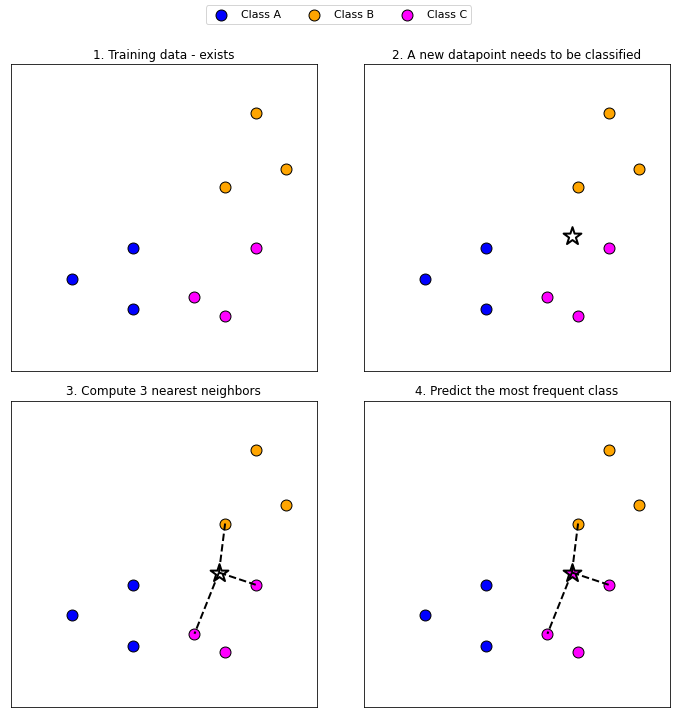

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# Data
# -----------------------------
X = np.array([
    [1.0, 1.5], [2, 2], [2, 1],      # class 0
    [4, 4.2], [3.5, 3], [4.5, 3.3],      # class 1
    [3, 1.2], [3.5, 0.9], [4, 2]       # class 2
])

y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])

colors = ["blue", "orange", "magenta"]
labels = ["Class A", "Class B", "Class C"]

new_point = np.array([[3.4, 2.2]])
k = 3

# -----------------------------
# KNN search
# -----------------------------
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(new_point)

nearest_indices = indices[0]
nearest_classes = y[nearest_indices]
predicted_class = np.bincount(nearest_classes).argmax()

# -----------------------------
# Helper plotting function
# -----------------------------
def plot_base(ax):
    for cls in np.unique(y):
        ax.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=120,
            color=colors[cls],
            edgecolor="black",
            label=labels[cls]
        )

    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)


# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# ---------------------------------
# (1) Training data
# ---------------------------------
ax = axes[0, 0]
plot_base(ax)
ax.set_title("1. Training data - exists")

# ---------------------------------
# (2) Add new point
# ---------------------------------
ax = axes[0, 1]
plot_base(ax)

ax.scatter(
    new_point[0, 0],
    new_point[0, 1],
    s=350,
    color="white",
    edgecolor="black",
    marker="*",
    linewidth=2
)

ax.set_title("2. A new datapoint needs to be classified")

# ---------------------------------
# (3) Connect nearest neighbors
# ---------------------------------
ax = axes[1, 0]
plot_base(ax)

ax.scatter(
    new_point[0, 0],
    new_point[0, 1],
    s=350,
    color="white",
    edgecolor="black",
    marker="*",
    linewidth=2
)

for idx in nearest_indices:
    ax.plot(
        [new_point[0, 0], X[idx, 0]],
        [new_point[0, 1], X[idx, 1]],
        linestyle="--",
        linewidth=2,
        color="black"
    )

ax.set_title(f"3. Compute {k} nearest neighbors")

# ---------------------------------
# (4) Final classification
# ---------------------------------
ax = axes[1, 1]
plot_base(ax)

for idx in nearest_indices:
    ax.plot(
        [new_point[0, 0], X[idx, 0]],
        [new_point[0, 1], X[idx, 1]],
        linestyle="--",
        linewidth=2,
        color="black"
    )

ax.scatter(
    new_point[0, 0],
    new_point[0, 1],
    s=350,
    color=colors[predicted_class],
    edgecolor="black",
    marker="*",
    linewidth=2
)

ax.set_title(f"4. Predict the most frequent class")

# Shared legend
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The performance of $\kappa$NN relies on the choice of the distance function and the number of neighbors $\kappa$. In addition, the $\kappa$NN classifier can be computationally very inefficient for big datasets, if it's implemented in a naive way. Hence, we discuss what we need to consider when appling $\kappa$NN in practice.
### Choosing a Distance Function
As a distance function we can use basically anything. Standard norm-induced distances are possible for continuous features
$$dist(\vvec{x}_i,\vvec{x}_j)=\lVert \vvec{x}_i - \vvec{x}_j\rVert,$$
but we can also integrate distance functions for discrete features, such as the Hamming distance (assuming $x$ reflects one categorical feature)
$$dist(x_i,x_j) = \begin{cases}1 & \text{ if }x_i\neq x_j\\0 & \text{ otherwise}\end{cases}$$

However, combining the distance functions over various kinds of features can be tricky and vastly influence the performance, as some distances may be weighted disproportionally to others.

### Choosing $\kappa$
The $\kappa$NN classifier has one hyperparameter: the number of neighbors $\kappa$. If $\kappa$ is very small, then the classifier tends to overfit and is sensitive to noise or outliers in the data. If $\kappa$ is too large, then the $\kappa$NN classifier tends to underfit.   

The plot below shows the decision boundary of the $\kappa$NN classifier for three values of $\kappa$ on the two moons synthetic dataset. The points reflect the training data set. For $\kappa=1$ we observe that the decision boundary is very fractured. We can imagine that a this decision boundary is very dependent on the data and hence the $\kappa$NN classifier with $\kappa=1$ has a high variance. The second value $\kappa=10$ is suitable to reflect the decision boundary of the two moons. It generalizes, since we observe that some of the red training data points in the area of the blue class do not influence the decision boundary. For $\kappa=50$ the model underfits. The shape of the two moons is not reflected by the decision boundary and the $\kappa$NN classifier resembles a linear classifier.  

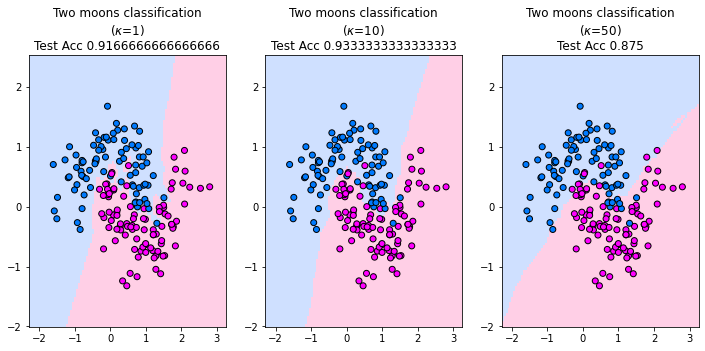

In [3]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
import numpy as np


X,y = make_moons(noise=0.3, random_state=0, n_samples=300)
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

_, axs = plt.subplots(ncols=3, figsize=(12, 5))
cm = ListedColormap(["#a0c3ff", "#ffa1cf"])
cm_points = ListedColormap(["#007bff", "magenta"])
for ax, k in zip(axs, (1,10,50)):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        knn,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        shading="auto",
        alpha=0.5,
        ax=ax,
        cmap=cm,
    )
    scatter = disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k",cmap = cm_points)
    _ = disp.ax_.set_title(
        f"Two moons classification\n($\kappa$={k})\nTest Acc {np.mean(knn.predict(X_test) == y_test)}"
    )

plt.show()


In practice, we can determine $\kappa$ by cross-validation or by means of the validation set.
```{note}
For binary classification, it is important to employ an odd number of $ \kappa $ nearest neighbors to prevent a voting tie between the two classes. 
```
### Computing the Nearest Neighbors
Computing a prediction of the $\kappa$NN classifier requires in principle the computation of distances to all datapoints, hence one prediction costs $\mathcal{O}(n)$. This is quite costly, and for bigger training datasets this quickly becomes too expensive. However, there are some common strategies that are applied in machine learning when we need to access local neighborhoods in an efficient manner. Two popular approaches to do so are kd-trees and locality-sensitive hashing.     

A k-dimensional tree (kd-tree) partitions the feature space recursively, allowing for faster nearest-neighbor queries in low-dimensional spaces ($d<20$). The search complexity is approximately $\mathcal{O}(\log n)$ in the average case.    

Locality-Sensitive Hashing (LSH) maps similar points to the same hash buckets. The proximity between points is reflected by their physical storage places. To find the nearest neighbors of a data point, we compute the hash key of this data point and access neighbors by looking into the hash buckets close to the hash bucket of the data point.

## Bayes consistency
Although the $\kappa$NN classifier is very simple, it is theoretically sound in the sense that we can show that it converges to the Bayes-optimal classifier in theory.
```{prf:theorem}
The $\kappa$NN classifier converges to the Bayes classifier for $n\rightarrow \infty$ when choosing $\kappa$ such that 
* $\kappa\rightarrow \infty$ and 
* $\frac{\kappa}{n}\rightarrow 0$.
```
A classifier that converges to the Bayes classifier if the size of the dataset grows infinitely is called **Bayes consistent**. A popular choice of $\kappa$ in practice is $\kappa=\sqrt{n}$. Hence, for this choice of $\kappa$, the $\kappa$NN classifier is also Bayes consistent.
